# Exploring the Clustering of Chicken Calls via Spectrograms
After generating clusters of chicken calls by their acousting features, this program takes that output and generates a bunch of spectrograms for calls within the same cluster so that they can be easily compared.  It aims to answer the question, do the statistically-generated clusters conform to how humans would suggest the sounds group together?

The program k_means_cluster_adult_chicken_calls.ipynb found 8 clusters with between 29-227 calls each.
The program k_means_cluster_chick_calls.ipynb found 4 clusters with between 57-82 calls each.

Steps:
1. Download the data and separate into different data frames for each cluster
2. Set up a function that takes in a data frame and randomly selects a certain number of rows from that dataframe (e.g., 10 rows). Each row has 1 call. For each row, it downloads the associated audio file, prints a 2-second spectrogram with the call outlined in the middle.
3. Run this function for each cluster
4. Compare visually the spectrograms for each cluster. Do they look more similar to each other than to the spectrograms of other clusters?

Note: Spectrograms have been removed prior to upload into github since they take up a lot of space, but can be easily regenerated locally by ensuring the audio files are available and uncommenting out the code. 

Author: K Rubio

Last modified: 3Aug26

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import librosa
import IPython.display as ipd
import numpy as np

In [2]:
from matplotlib.figure import Figure
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
from typing import TypedDict, Literal

In [3]:
# have to modify where notebook looks for imports so it looks in the project root, not the notebook folder
os.getcwd()
sys.path.append(str(Path().resolve().parent.parent))
print(sys.path)

['/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python312.zip', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12/lib-dynload', '', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/ML_and_Data_Science/Audio Signal Processing/Completed Projects/2026_04_Audio_Signal_Analysis/audio-signal-analysis/.venv/lib/python3.12/site-packages', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/ML_and_Data_Science/Audio Signal Processing/Completed Projects/2026_04_Audio_Signal_Analysis/audio-signal-analysis']


In [4]:
from utils.frequency_domain_utils import (
  plot_spectrogram_zoom,
  short_time_fourier_transform,
)

In [ ]:
# import the data
filename = "chickens_2024_egg_song_flo"
df = pd.read_csv(f"../../data/output/chickens/{filename}.csv")
filename2 = "2026-07-31_cluster_chicks_analysis_output"
df_chicks = pd.read_csv(f"../../data/output/chickens/{filename2}.csv")
#df

In [ ]:
# separate into separate dataframes for each cluster
df0 = df[df['cluster'] == 0]
df1 = df[df['cluster'] == 1]
df2 = df[df['cluster'] == 2]
df3 = df[df['cluster'] == 3]
df4 = df[df['cluster'] == 4]
df5 = df[df['cluster'] == 5]
df6 = df[df['cluster'] == 6]
df7 = df[df['cluster'] == 7]

df_chicks0 = df_chicks[df_chicks['cluster'] == 0]
df_chicks1 = df_chicks[df_chicks['cluster'] == 1]
df_chicks2 = df_chicks[df_chicks['cluster'] == 2]
df_chicks3 = df_chicks[df_chicks['cluster'] == 3]

In [ ]:
FRAME_LENGTH = 512 # powers of 2 include 256, 512, 1024
HOP_LENGTH = FRAME_LENGTH//4

In [ ]:
TIME_PADDING = 1 # number of seconds before and after the center of the call
NUM_TO_CHECK = 10

# Randomly sample a certain number of rows from a dataset that has "filename" and "call_num" as columns
# print 2 seconds of spectrogram with the target call outlined in the middle. Outlinining seems to be a
# little off on very short calls perhaps due to some rounding/truncating number issues
def print_multiple_spectrograms(df, NUM_TO_CHECK):

  for i, row in df.sample(n=NUM_TO_CHECK, random_state=42).iterrows():
    filename = row['filename']
    filepath = f'../../data/audio/chickens/{filename}'
    file, sr = librosa.load(filepath)
    ipd.Audio(file, rate=sr)
    stft = short_time_fourier_transform(file, FRAME_LENGTH, HOP_LENGTH)

    regions = [{"start": row["start"], "end": row["end"]}]

    time_center = row["start"] + row["duration_ms"]/1000/2

    title = f"{filename} call #{row['call_num']} in cluster {row['cluster']}"
    plot_spectrogram_zoom(stft, sr, HOP_LENGTH, "linear", 0, sr / 2, time_center-TIME_PADDING, time_center+TIME_PADDING, regions, "lines", title)

## Adult Chickens Cluster 0

In [ ]:
# print_multiple_spectrograms(df0, NUM_TO_CHECK)

## Adult Chickens Cluster 1

In [ ]:
# print_multiple_spectrograms(df1, NUM_TO_CHECK)

## Adult Chickens Cluster 2

In [104]:
# print_multiple_spectrograms(df2, NUM_TO_CHECK)

## Adult Chickens Cluster 3

In [113]:
# print_multiple_spectrograms(df3, NUM_TO_CHECK)

## Adult Chickens Cluster 4

In [105]:
# print_multiple_spectrograms(df4, NUM_TO_CHECK)

## Adult Chickens Cluster 5

In [112]:
# print_multiple_spectrograms(df5, NUM_TO_CHECK)

## Adult Chickens Cluster 6

In [106]:
# print_multiple_spectrograms(df6, NUM_TO_CHECK)

## Adult Chickens Cluster 7

In [111]:
# print_multiple_spectrograms(df7, NUM_TO_CHECK)

## Chicks Cluster 0

In [107]:
# print_multiple_spectrograms(df_chicks0, NUM_TO_CHECK)

## Chicks Cluster 1

In [110]:
# print_multiple_spectrograms(df_chicks1, NUM_TO_CHECK)

## Chicks Cluster 2

In [108]:
# print_multiple_spectrograms(df_chicks2, NUM_TO_CHECK)

## Chicks Cluster 3

In [109]:
# print_multiple_spectrograms(df_chicks3, NUM_TO_CHECK)

In [5]:
FRAME_LENGTH = 512
HOP_LENGTH = 128

(<Figure size 2500x1000 with 1 Axes>,
 <Axes: title={'center': 'chickens_2024_egg_song_wasilly.wav'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>)

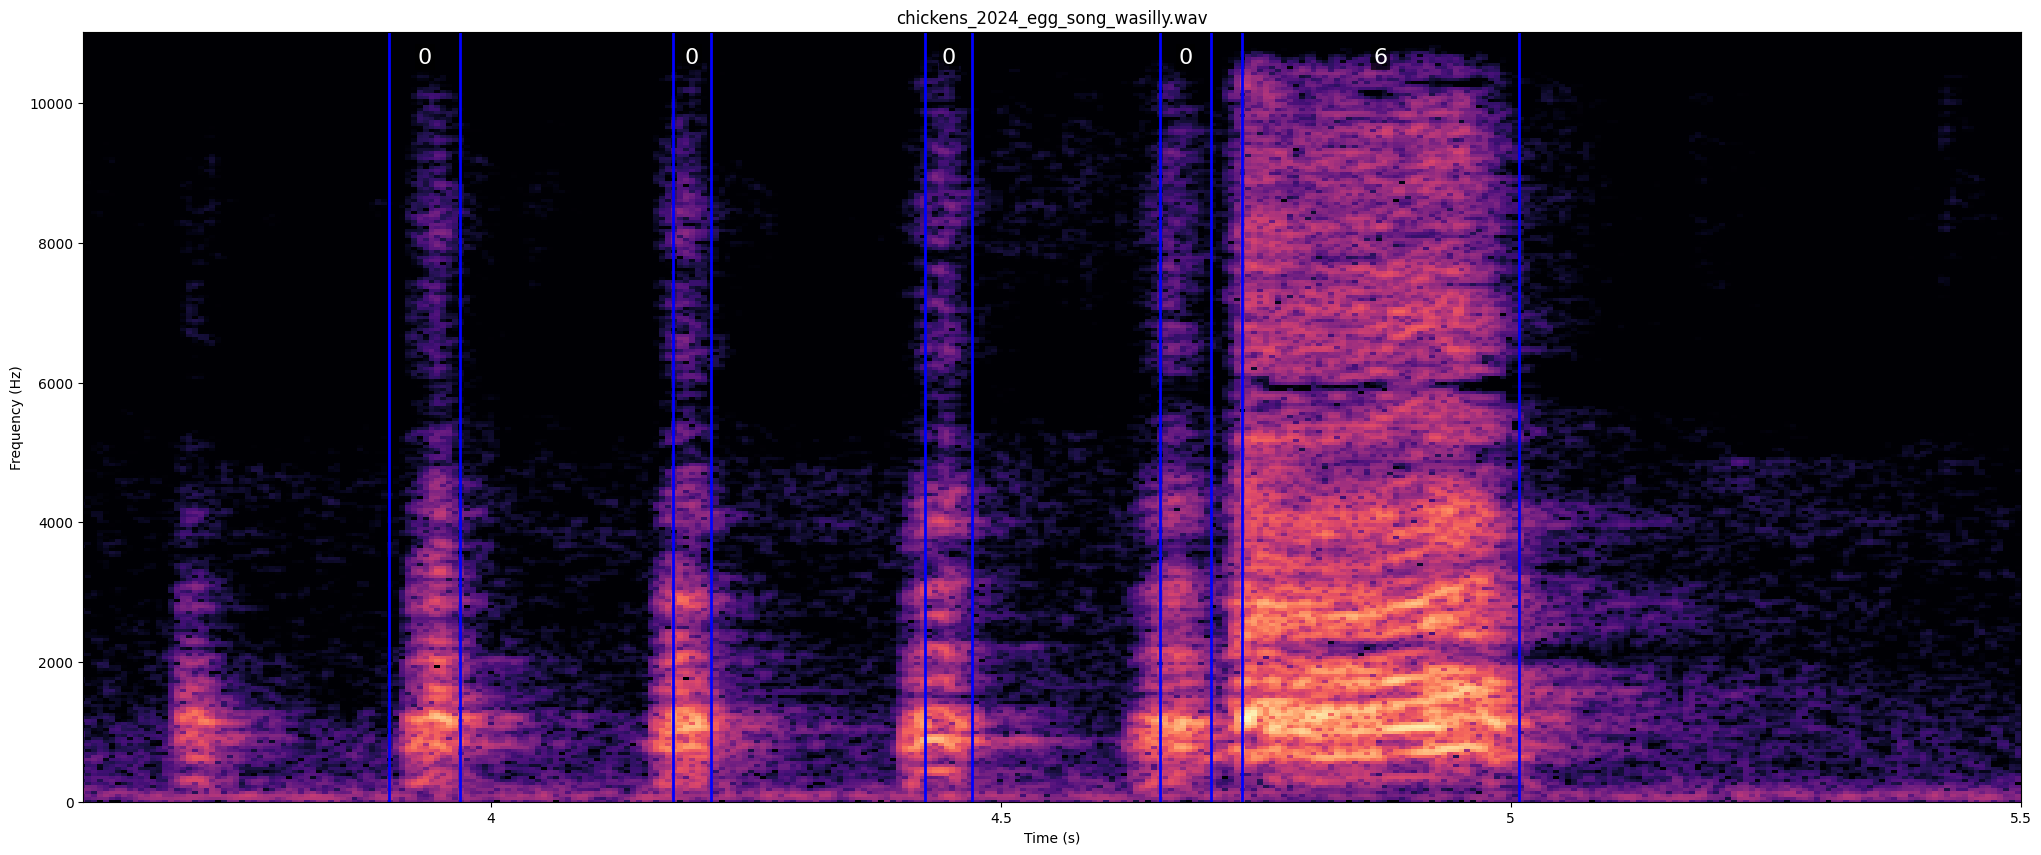

In [11]:
filename = "chickens_2024_egg_song_wasilly.wav"
filepath = f'../../data/audio/chickens/{filename}'
file, sr = librosa.load(filepath)

stft = short_time_fourier_transform(file, FRAME_LENGTH, HOP_LENGTH)

#regions = [{"start": row["start"], "end": row["end"]}]
regions = [
  {"start": 3.9, "end": 3.97, "label": "0"},
  {"start": 4.178, "end": 4.216, "label": "0"},
  {"start": 4.426, "end": 4.472, "label": "0"},
  {"start": 4.656, "end": 4.706, "label": "0"},
  {"start": 4.736, "end": 5.008, "label": "6"}
]

title = f"{filename}"
plot_spectrogram_zoom(stft, sr, HOP_LENGTH, "linear", 0, sr / 2, 3.6, 5.5, regions, "lines", title)


In [ ]:

{"start": 0.002, "end": 0.03, "label": "0"},
  {"start": 0.202, "end": 0.236, "label": "0"},
  {"start": 0.452, "end": 0.488, "label": "0"},
  {"start": 0.692, "end": 0.734, "label": "0"},
  {"start": 0.946, "end": 0.98, "label": "0"},
  {"start": 1.204, "end": 1.244, "label": "0"},
  {"start": 1.462, "end": 1.5, "label": "0"},
  {"start": 1.712, "end": 1.75, "label": "0"},
  {"start": 1.972, "end": 2, "label": "0"},
  {"start": 2.26	, "end": 2.308, "label": "0"},
